In [6]:
import numpy as np
from scipy.signal import fftconvolve as convolve
from scipy.signal import lfilter

s = np.array([3, 2, 1, 0, 1, 2, 3])
h = np.array([-1, 1, 2, -1])

y_conv = np.array(convolve(s, h))
y_filt = np.array(lfilter(h, 1.0, s))

def conv(signal, filter_array):
  N = signal.size
  M = filter_array.size

  result = np.zeros(N + M - 1)
  s = np.concatenate((signal, np.zeros(M - 1)))
  h = np.concatenate((filter_array, np.zeros(N - 1)))

  for n in range(N + M - 1):
    for m in range(N + M - 1):
      if n < m:
        continue
      result[n] += s[m] * h[n - m]
    # for m in range(n):
    #   result[n] += s[m] * h[n - m]

  return result

my_conv = conv(s, h)

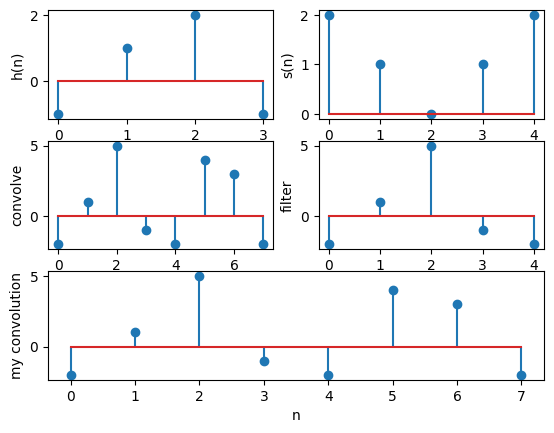

In [5]:
import matplotlib.pyplot as plt

fig = plt.figure()

gs = fig.add_gridspec(3,2)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])
ax5 = fig.add_subplot(gs[2, :])

ax1.stem(h)
ax1.set(xlabel='n', ylabel='h(n)')

ax2.stem(s)
ax2.set(xlabel='n', ylabel='s(n)')

ax3.stem(y_conv)
ax3.set(xlabel='n', ylabel='convolve')

ax4.stem(y_filt)
ax4.set(xlabel='n', ylabel='filter')

ax5.stem(my_conv)
ax5.set(xlabel='n', ylabel='my convolution')

plt.show()

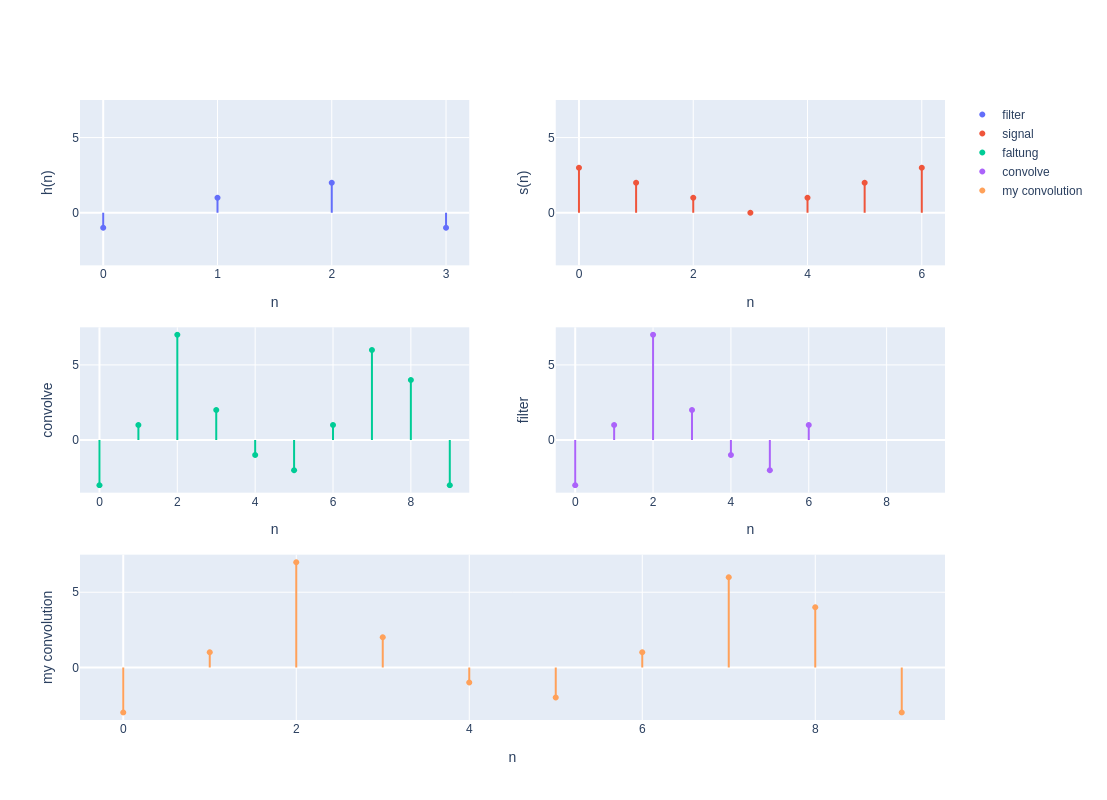

In [8]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(rows=3, cols=2,
  specs=[
    [{}, {}],
    [{}, {}],
    [{"colspan": 2}, None]])
fig.add_trace(
  go.Scatter(
    y=h,
    error_y=dict(type='data', symmetric=False, arrayminus=h, array=[0]*h.size, width=0),
    name='filter',
    mode='markers'
  ), row=1, col=1
)
fig.add_trace(
  go.Scatter(
    y=s,
    error_y=dict(type='data', symmetric=False, arrayminus=s, array=[0]*s.size, width=0),
    name='signal',
    mode='markers'
  ), row=1, col=2
)
fig.add_trace(
  go.Scatter(
    y=y_conv,
    error_y=dict(type='data', symmetric=False, arrayminus=y_conv, array=[0]*y_conv.size, width=0),
    name='faltung',
    mode='markers'
  ), row=2, col=1
)
fig.add_trace(
  go.Scatter(
    y=y_filt,
    error_y=dict(type='data', symmetric=False, arrayminus=y_filt, array=[0]*y_filt.size, width=0),
    name='convolve',
    mode='markers'
  ), row=2, col=2
)
fig.add_trace(
  go.Scatter(
    y=my_conv,
    error_y=dict(type='data', symmetric=False, arrayminus=my_conv, array=[0]*my_conv.size, width=0),
    name='my convolution',
    mode='markers'
  ), row=3, col=[1,2]
)
axis_delta = 0.5
r = [np.min(y_conv)-axis_delta, np.max(y_conv)+axis_delta]
fig.update_layout(
    height=800,
  xaxis1=dict(title='n'),
  xaxis2=dict(title='n'),
  xaxis3=dict(title='n', range=[-axis_delta, y_conv.size-axis_delta]),
  xaxis4=dict(title='n', range=[-axis_delta, y_conv.size-axis_delta]),
  xaxis5=dict(title='n', range=[-axis_delta, y_conv.size-axis_delta]),
  yaxis1=dict(title='h(n)', range=r),
  yaxis2=dict(title='s(n)', range=r),
  yaxis3=dict(title='convolve', range=r),
  yaxis4=dict(title='filter', range=r),
  yaxis5=dict(title='my convolution', range=r),
)
fig.show()